<a href="https://colab.research.google.com/github/sunkaravivek/ML-23CSE302/blob/main/lab-8/8.5_svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn import metrics
from sklearn.metrics import classification_report
import seaborn as sn
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('/content/BreastCancer.csv')

print(data.head())
print(data.shape)

        Id  Cl.thickness  Cell.size  Cell.shape  Marg.adhesion  Epith.c.size  \
0  1000025             5          1           1              1             2   
1  1002945             5          4           4              5             7   
2  1015425             3          1           1              1             2   
3  1016277             6          8           8              1             3   
4  1017023             4          1           1              3             2   

   Bare.nuclei  Bl.cromatin  Normal.nucleoli  Mitoses  Class  
0          1.0            3                1        1      0  
1         10.0            3                2        1      0  
2          2.0            3                1        1      0  
3          4.0            3                7        1      0  
4          1.0            3                1        1      0  
(699, 11)


In [4]:
print(data.columns)
print(data.isnull().sum())

Index(['Id', 'Cl.thickness', 'Cell.size', 'Cell.shape', 'Marg.adhesion',
       'Epith.c.size', 'Bare.nuclei', 'Bl.cromatin', 'Normal.nucleoli',
       'Mitoses', 'Class'],
      dtype='object')
Id                  0
Cl.thickness        0
Cell.size           0
Cell.shape          0
Marg.adhesion       0
Epith.c.size        0
Bare.nuclei        16
Bl.cromatin         0
Normal.nucleoli     0
Mitoses             0
Class               0
dtype: int64


In [18]:
X = data.drop('Class', axis=1)

# Remove ID column
X = X.drop('Id', axis=1)

# Convert ? to NaN
X = X.replace('?', pd.NA)

# Convert all columns to numeric
X = X.apply(pd.to_numeric)

# Fill missing values with the column median
X = X.fillna(X.median())

y = data['Class']

In [31]:
y = data['Class']

print(y.unique())
print(y.isnull().sum())

[0 1]
0


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=5
)

In [33]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [34]:
model = SVC(kernel='rbf', random_state=0)

model.fit(X_train, y_train)

svc_prediction = model.predict(X_test)

In [35]:
conf_mat = metrics.confusion_matrix(y_test, svc_prediction)

print("SVC [kernel - rbf]")
print("Confusion Matrix:")
print(conf_mat)

Accuracy_score = metrics.accuracy_score(y_test, svc_prediction)

print("Accuracy Score:", Accuracy_score)
print("Accuracy in Percentage:", int(Accuracy_score * 100), "%")

print(classification_report(y_test, svc_prediction))

SVC [kernel - rbf]
Confusion Matrix:
[[131   8]
 [  5  66]]
Accuracy Score: 0.9380952380952381
Accuracy in Percentage: 93 %
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       139
           1       0.89      0.93      0.91        71

    accuracy                           0.94       210
   macro avg       0.93      0.94      0.93       210
weighted avg       0.94      0.94      0.94       210



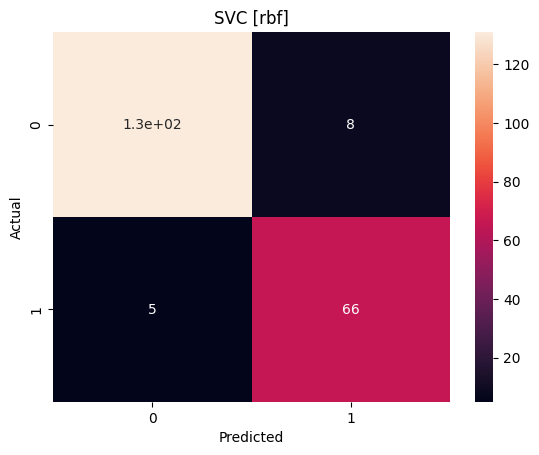

In [36]:
conf_mat = pd.crosstab(
    y_test,
    svc_prediction,
    rownames=['Actual'],
    colnames=['Predicted']
)

sn.heatmap(conf_mat, annot=True)

plt.title("SVC [rbf]")
plt.show()

In [40]:
model = SVC(kernel='linear', random_state=0)

model.fit(X_train, y_train)

svc_prediction = model.predict(X_test)

In [41]:
conf_mat = metrics.confusion_matrix(y_test, svc_prediction)

print("SVC [kernel - linear]")
print("Confusion Matrix:")
print(conf_mat)

Accuracy_score = metrics.accuracy_score(y_test, svc_prediction)

print("Accuracy Score:", Accuracy_score)
print("Accuracy in Percentage:", int(Accuracy_score * 100), "%")

print(classification_report(y_test, svc_prediction))

SVC [kernel - linear]
Confusion Matrix:
[[133   6]
 [  5  66]]
Accuracy Score: 0.9476190476190476
Accuracy in Percentage: 94 %
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       139
           1       0.92      0.93      0.92        71

    accuracy                           0.95       210
   macro avg       0.94      0.94      0.94       210
weighted avg       0.95      0.95      0.95       210



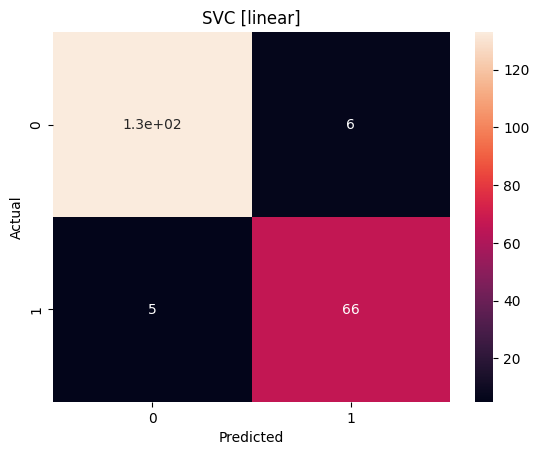

In [42]:
conf_mat = pd.crosstab(
    y_test,
    svc_prediction,
    rownames=['Actual'],
    colnames=['Predicted']
)

sn.heatmap(conf_mat, annot=True)

plt.title("SVC [linear]")
plt.show()